In [ ]:
import kagglehub

In [ ]:
path = kagglehub.dataset_download(
    "sovitrath/diabetic-retinopathy-224x224-2019-data"
)

print("Dataset path:", path)

DATASET_PATH = os.path.join(path, "colored_images")

print(os.listdir(DATASET_PATH))

Using Colab cache for faster access to the 'diabetic-retinopathy-224x224-2019-data' dataset.
Dataset path: /kaggle/input/diabetic-retinopathy-224x224-2019-data
['Mild', 'Proliferate_DR', 'Moderate', 'No_DR', 'Severe']


In [ ]:
# ============================================================
# 1. INSTALL DEPENDENCIES
# ============================================================

!pip install -q kagglehub
!pip install -q timm
!pip install -q grad-cam
!pip install -q seaborn

In [ ]:
# ============================================================
# 2. IMPORTS
# ============================================================

import os
import cv2
import timm
import torch
import shutil
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from PIL import Image

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    roc_curve,
    auc
)

from sklearn.preprocessing import label_binarize

import tensorflow as tf

from tensorflow.keras.applications import EfficientNetV2B0
from tensorflow.keras.layers import (
    Dense,
    Dropout,
    GlobalAveragePooling2D
)

from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.image import (
    ImageDataGenerator
)

import torch.nn as nn
import torch.optim as optim

from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image

import kagglehub

In [ ]:
# ============================================================
# 3. DOWNLOAD DATASET
# ============================================================

path = kagglehub.dataset_download(
    "sovitrath/diabetic-retinopathy-224x224-2019-data"
)

DATASET_PATH = os.path.join(
    path,
    "colored_images"
)

print(os.listdir(DATASET_PATH))

Using Colab cache for faster access to the 'diabetic-retinopathy-224x224-2019-data' dataset.
['Mild', 'Proliferate_DR', 'Moderate', 'No_DR', 'Severe']


In [ ]:
# ============================================================
# 4. CREATE DATAFRAME
# ============================================================

data = []

for class_name in os.listdir(DATASET_PATH):

    class_path = os.path.join(
        DATASET_PATH,
        class_name
    )

    for img_name in os.listdir(class_path):

        img_path = os.path.join(
            class_path,
            img_name
        )

        data.append({
            "filepath": img_path,
            "label": class_name
        })

df = pd.DataFrame(data)

print(df["label"].value_counts())

label
No_DR             1805
Moderate           999
Mild               370
Proliferate_DR     295
Severe             193
Name: count, dtype: int64


In [ ]:
# ============================================================
# 5. TRAIN VALIDATION SPLIT
# ============================================================

train_df, val_df = train_test_split(
    df,
    test_size=0.2,
    stratify=df["label"],
    random_state=42
)

# ============================================================
# ============================================================
# STAGE 1
# EfficientNetV2B0 Binary Classifier

In [ ]:
# ============================================================
# 6. CREATE BINARY LABELS
# ============================================================

def binary_label(label):

    if label == "No_DR":
        return "No_DR"

    return "DR"

train_df["binary_label"] = train_df[
    "label"
].apply(binary_label)

val_df["binary_label"] = val_df[
    "label"
].apply(binary_label)


In [ ]:
# ============================================================
# 7. IMAGE GENERATORS
# ============================================================

IMG_SIZE = 224
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(

    rescale=1./255,

    rotation_range=20,

    horizontal_flip=True,

    zoom_range=0.2
)

val_datagen = ImageDataGenerator(
    rescale=1./255
)

In [ ]:
# ============================================================
# 8. BINARY GENERATORS
# ============================================================

train_generator = train_datagen.flow_from_dataframe(

    dataframe=train_df,

    x_col="filepath",

    y_col="binary_label",

    target_size=(224,224),

    batch_size=BATCH_SIZE,

    class_mode="binary"
)

val_generator = val_datagen.flow_from_dataframe(

    dataframe=val_df,

    x_col="filepath",

    y_col="binary_label",

    target_size=(224,224),

    batch_size=BATCH_SIZE,

    class_mode="binary"
)

Found 2929 validated image filenames belonging to 2 classes.
Found 733 validated image filenames belonging to 2 classes.


In [ ]:
# ============================================================
# 9. EFFICIENTNETV2B0 MODEL
# ============================================================

base_model = EfficientNetV2B0(

    weights='imagenet',

    include_top=False,

    input_shape=(224,224,3)
)

base_model.trainable = False

x = base_model.output

x = GlobalAveragePooling2D()(x)

x = Dropout(0.3)(x)

output = Dense(
    1,
    activation='sigmoid'
)(x)

binary_model = Model(
    inputs=base_model.input,
    outputs=output
)


In [ ]:
# ============================================================
# 10. COMPILE BINARY MODEL
# ============================================================

binary_model.compile(

    optimizer='adam',

    loss='binary_crossentropy',

    metrics=[
        'accuracy',
        tf.keras.metrics.Recall(
            name='sensitivity'
        ),
        tf.keras.metrics.AUC(
            name='auc'
        )
    ]
)

In [ ]:
# ============================================================
# 11. TRAIN STAGE 1
# ============================================================

history_stage1 = binary_model.fit(

    train_generator,

    validation_data=val_generator,

    epochs=5
)


Epoch 1/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 110s 903ms/step - accuracy: 0.4978 - auc: 0.4998 - loss: 0.7031 - sensitivity: 0.4820 - val_accuracy: 0.5075 - val_auc: 0.5000 - val_loss: 0.6936 - val_sensitivity: 0.0000e+00
Epoch 2/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 50s 543ms/step - accuracy: 0.4916 - auc: 0.4908 - loss: 0.7023 - sensitivity: 0.4467 - val_accuracy: 0.4925 - val_auc: 0.5000 - val_loss: 0.6965 - val_sensitivity: 1.0000
Epoch 3/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 50s 548ms/step - accuracy: 0.4964 - auc: 0.4973 - loss: 0.7007 - sensitivity: 0.4328 - val_accuracy: 0.4925 - val_auc: 0.5013 - val_loss: 0.6931 - val_sensitivity: 1.0000
Epoch 4/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 49s 530ms/step - accuracy: 0.4978 - auc: 0.4987 - loss: 0.6993 - sensitivity: 0.4411 - val_accuracy: 0.4925 - val_auc: 0.5456 - val_loss: 0.7027 - val_sensitivity: 1.0000
Epoch 5/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 49s 533ms/step - accuracy: 0.5036 - auc: 0.5056 - loss: 0.6990 - sensitivity: 0.4771 - val_accuracy: 0.5075 - val_auc: 0.4913 

In [ ]:
# ============================================================
# 12. FINE TUNE BINARY MODEL
# ============================================================

base_model.trainable = True

binary_model.compile(

    optimizer=tf.keras.optimizers.Adam(
        1e-5
    ),

    loss='binary_crossentropy',

    metrics=[
        'accuracy',
        tf.keras.metrics.Recall(
            name='sensitivity'
        ),
        tf.keras.metrics.AUC(
            name='auc'
        )
    ]
)

history_stage1_ft = binary_model.fit(

    train_generator,

    validation_data=val_generator,

    epochs=10
)

Epoch 1/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 232s 1s/step - accuracy: 0.7156 - auc: 0.7861 - loss: 0.6066 - sensitivity: 0.7133 - val_accuracy: 0.8158 - val_auc: 0.9206 - val_loss: 0.5410 - val_sensitivity: 0.9446
Epoch 2/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 48s 517ms/step - accuracy: 0.8313 - auc: 0.9130 - loss: 0.4594 - sensitivity: 0.8054 - val_accuracy: 0.8868 - val_auc: 0.9468 - val_loss: 0.3857 - val_sensitivity: 0.9003
Epoch 3/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 46s 499ms/step - accuracy: 0.8696 - auc: 0.9401 - loss: 0.3650 - sensitivity: 0.8504 - val_accuracy: 0.9031 - val_auc: 0.9539 - val_loss: 0.3184 - val_sensitivity: 0.9169
Epoch 4/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 48s 515ms/step - accuracy: 0.9006 - auc: 0.9533 - loss: 0.3036 - sensitivity: 0.8920 - val_accuracy: 0.9127 - val_auc: 0.9551 - val_loss: 0.2915 - val_sensitivity: 0.9418
Epoch 5/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 48s 517ms/step - accuracy: 0.9170 - auc: 0.9634 - loss: 0.2598 - sensitivity: 0.9107 - val_accuracy: 0.9277 - val_auc: 0.9600 - 

In [ ]:

# ============================================================
# 13. SAVE BINARY MODEL
# ============================================================

binary_model.save(
    "efficientnetv2b0_binary_dr.h5"
)

print("Binary model saved.")

# ============================================================
# ============================================================
# STAGE 2
# SWIN TRANSFORMER SEVERITY CLASSIFIER
# ============================================================
# ============================================================

Binary model saved.


In [ ]:

# ============================================================
# 14. REMOVE NO_DR
# ============================================================

train_df_stage2 = train_df[
    train_df["label"] != "No_DR"
]

val_df_stage2 = val_df[
    val_df["label"] != "No_DR"
]

In [ ]:
# ============================================================
# 15. LABEL MAP
# ============================================================

label_map = {

    "Mild": 0,

    "Moderate": 1,

    "Severe": 2,

    "Proliferate_DR": 3
}

reverse_label_map = {

    0: "Mild",

    1: "Moderate",

    2: "Severe",

    3: "Proliferate_DR"
}


In [ ]:
# ============================================================
# 16. DATASET CLASS
# ============================================================

class DRDataset(Dataset):

    def __init__(self, dataframe, transform=None):

        self.dataframe = dataframe.reset_index(drop=True)

        self.transform = transform

    def __len__(self):

        return len(self.dataframe)

    def __getitem__(self, idx):

        img_path = self.dataframe.iloc[idx]["filepath"]

        label = self.dataframe.iloc[idx]["label"]

        image = Image.open(
            img_path
        ).convert("RGB")

        if self.transform:
            image = self.transform(image)

        label = label_map[label]

        return image, label


In [ ]:

# ============================================================
# 17. TRANSFORMS
# ============================================================

train_transform = transforms.Compose([

    transforms.Resize((224,224)),

    transforms.RandomHorizontalFlip(),

    transforms.RandomRotation(10),

    transforms.ToTensor(),

    transforms.Normalize(

        mean=[0.485, 0.456, 0.406],

        std=[0.229, 0.224, 0.225]
    )
])

val_transform = transforms.Compose([

    transforms.Resize((224,224)),

    transforms.ToTensor(),

    transforms.Normalize(

        mean=[0.485, 0.456, 0.406],

        std=[0.229, 0.224, 0.225]
    )
])

In [ ]:
# ============================================================
# 18. DATASETS
# ============================================================

train_dataset = DRDataset(

    train_df_stage2,

    transform=train_transform
)

val_dataset = DRDataset(

    val_df_stage2,

    transform=val_transform
)


In [ ]:
# ============================================================
# 19. DATALOADERS
# ============================================================

train_loader = DataLoader(

    train_dataset,

    batch_size=32,

    shuffle=True,

    num_workers=2
)

val_loader = DataLoader(

    val_dataset,

    batch_size=32,

    shuffle=False,

    num_workers=2
)


In [ ]:
# ============================================================
# 20. DEVICE
# ============================================================

device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

print(device)

cuda


In [ ]:
# ============================================================
# 21. SWIN TRANSFORMER MODEL
# ============================================================

model = timm.create_model(

    'swin_base_patch4_window7_224',

    pretrained=True,

    num_classes=4
)

model = model.to(device)

In [ ]:
# ============================================================
# 22. FREEZE BACKBONE
# ============================================================

for param in model.parameters():
    param.requires_grad = False

for param in model.head.parameters():
    param.requires_grad = True


In [ ]:
# ============================================================
# 23. LOSS + OPTIMIZER
# ============================================================

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(

    model.parameters(),

    lr=1e-3
)


In [ ]:
# ============================================================
# 24. OUTPUT FOLDERS
# ============================================================

OUTPUT_DIR = "outputs"

os.makedirs(
    OUTPUT_DIR,
    exist_ok=True
)

os.makedirs(
    f"{OUTPUT_DIR}/gradcam/correct",
    exist_ok=True
)

os.makedirs(
    f"{OUTPUT_DIR}/gradcam/wrong",
    exist_ok=True
)


In [ ]:

# ============================================================
# 25. TRAINING METRICS
# ============================================================

train_losses = []

val_accuracies = []

In [ ]:

# ============================================================
# 26. STAGE 1 TRAINING
# ============================================================

EPOCHS_STAGE1 = 5

for epoch in range(EPOCHS_STAGE1):

    model.train()

    running_loss = 0

    for images, labels in train_loader:

        images = images.to(device)

        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(
            outputs,
            labels
        )

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    avg_loss = running_loss / len(train_loader)

    train_losses.append(avg_loss)

    # ================= VALIDATION =================

    model.eval()

    preds = []

    true_labels = []

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)

            outputs = model(images)

            pred_classes = torch.argmax(
                outputs,
                dim=1
            )

            preds.extend(
                pred_classes.cpu().numpy()
            )

            true_labels.extend(
                labels.numpy()
            )

    acc = accuracy_score(
        true_labels,
        preds
    )

    val_accuracies.append(acc)

    print(f"\nEpoch {epoch+1}")

    print(f"Loss: {avg_loss:.4f}")

    print(f"Validation Accuracy: {acc:.4f}")



Epoch 1
Loss: 1.1432
Validation Accuracy: 0.5376

Epoch 2
Loss: 0.9997
Validation Accuracy: 0.5806

Epoch 3
Loss: 0.9486
Validation Accuracy: 0.5968

Epoch 4
Loss: 0.9147
Validation Accuracy: 0.6102

Epoch 5
Loss: 0.9035
Validation Accuracy: 0.5995


In [ ]:

# ============================================================
# 27. FULL FINE TUNING
# ============================================================

for param in model.parameters():
    param.requires_grad = True

optimizer = optim.Adam(

    model.parameters(),

    lr=1e-5
)

EPOCHS_STAGE2 = 15

for epoch in range(EPOCHS_STAGE2):

    model.train()

    running_loss = 0

    for images, labels in train_loader:

        images = images.to(device)

        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(
            outputs,
            labels
        )

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    avg_loss = running_loss / len(train_loader)

    train_losses.append(avg_loss)

    # ================= VALIDATION =================

    model.eval()

    preds = []

    true_labels = []

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)

            outputs = model(images)

            pred_classes = torch.argmax(
                outputs,
                dim=1
            )

            preds.extend(
                pred_classes.cpu().numpy()
            )

            true_labels.extend(
                labels.numpy()
            )

    acc = accuracy_score(
        true_labels,
        preds
    )

    val_accuracies.append(acc)

    print(f"\nFineTune Epoch {epoch+1}")

    print(f"Loss: {avg_loss:.4f}")

    print(f"Validation Accuracy: {acc:.4f}")


FineTune Epoch 1
Loss: 0.8600
Validation Accuracy: 0.6774

FineTune Epoch 2
Loss: 0.7222
Validation Accuracy: 0.6774

FineTune Epoch 3
Loss: 0.6662
Validation Accuracy: 0.6962

FineTune Epoch 4
Loss: 0.6399
Validation Accuracy: 0.6855

FineTune Epoch 5
Loss: 0.5645
Validation Accuracy: 0.7016

FineTune Epoch 6
Loss: 0.5643
Validation Accuracy: 0.7043

FineTune Epoch 7
Loss: 0.4981
Validation Accuracy: 0.7231

FineTune Epoch 8
Loss: 0.4574
Validation Accuracy: 0.7258

FineTune Epoch 9
Loss: 0.4336
Validation Accuracy: 0.6747

FineTune Epoch 10
Loss: 0.4085
Validation Accuracy: 0.6962

FineTune Epoch 11
Loss: 0.3909
Validation Accuracy: 0.7204

FineTune Epoch 12
Loss: 0.3262
Validation Accuracy: 0.7097

FineTune Epoch 13
Loss: 0.3113
Validation Accuracy: 0.7097

FineTune Epoch 14
Loss: 0.2932
Validation Accuracy: 0.6774

FineTune Epoch 15
Loss: 0.2490
Validation Accuracy: 0.7016


In [ ]:
# ============================================================
# 28. SAVE SWIN CHECKPOINT
# ============================================================

torch.save({

    'model_state_dict':
        model.state_dict(),

    'optimizer_state_dict':
        optimizer.state_dict()

}, "swin_checkpoint.pth")

# ============================================================
# 29. SAVE SWIN MODEL
# ============================================================

torch.save(

    model.state_dict(),

    "swin_transformer_dr.pth"
)

torch.save(

    model,

    "complete_swin_model.pth"
)


In [ ]:
# ============================================================
# 30. FINAL EVALUATION
# ============================================================

model.eval()

preds = []

true_labels = []

all_probs = []

with torch.no_grad():

    for images, labels in val_loader:

        images = images.to(device)

        outputs = model(images)

        probs = torch.softmax(
            outputs,
            dim=1
        )

        pred_classes = torch.argmax(
            outputs,
            dim=1
        )

        preds.extend(
            pred_classes.cpu().numpy()
        )

        true_labels.extend(
            labels.numpy()
        )

        all_probs.extend(
            probs.cpu().numpy()
        )

all_probs = np.array(all_probs)


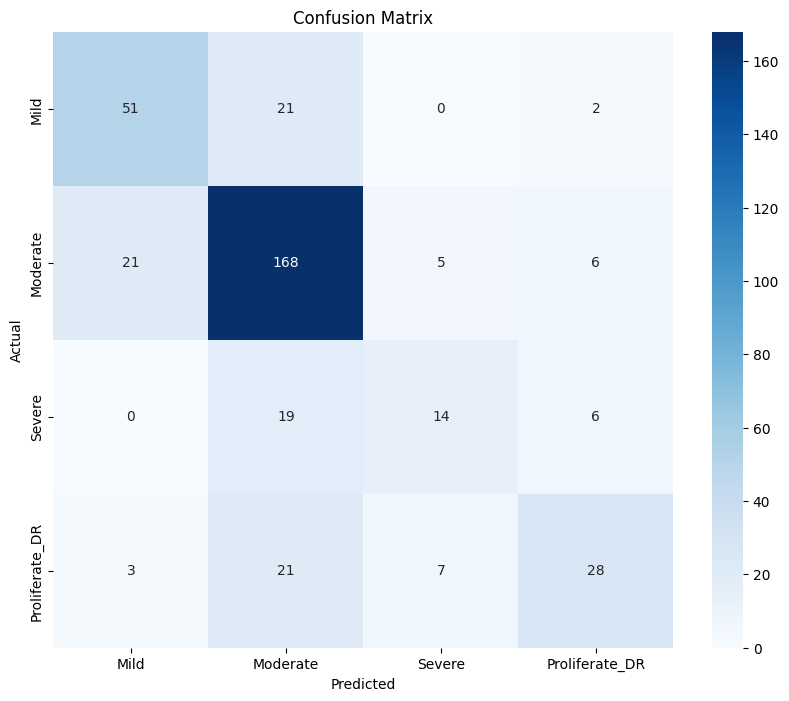

In [ ]:
# ============================================================
# 31. CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(
    true_labels,
    preds
)

class_names = [

    "Mild",

    "Moderate",

    "Severe",

    "Proliferate_DR"
]

plt.figure(figsize=(10,8))

sns.heatmap(

    cm,

    annot=True,

    fmt='d',

    cmap='Blues',

    xticklabels=class_names,

    yticklabels=class_names
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.savefig(
    f"{OUTPUT_DIR}/confusion_matrix.png"
)

plt.show()


In [ ]:
# ============================================================
# 32. CLASSIFICATION REPORT
# ============================================================

report = classification_report(

    true_labels,

    preds,

    target_names=class_names
)

print(report)

with open(

    f"{OUTPUT_DIR}/classification_report.txt",

    "w"

) as f:

    f.write(report)



                precision    recall  f1-score   support

          Mild       0.68      0.69      0.68        74
      Moderate       0.73      0.84      0.78       200
        Severe       0.54      0.36      0.43        39
Proliferate_DR       0.67      0.47      0.55        59

      accuracy                           0.70       372
     macro avg       0.65      0.59      0.61       372
  weighted avg       0.69      0.70      0.69       372



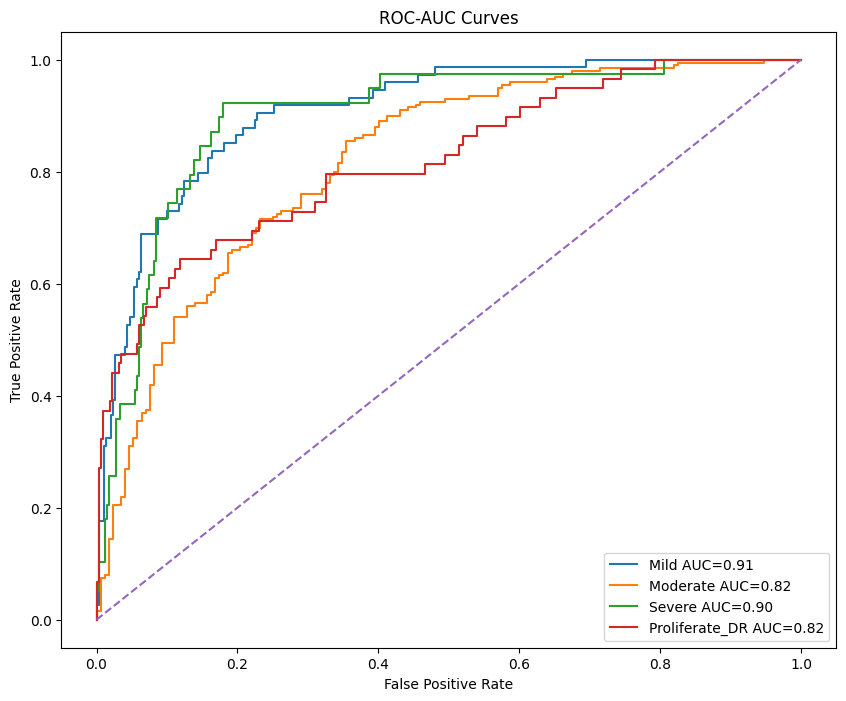

In [ ]:
# ============================================================
# 33. ROC AUC
# ============================================================

y_bin = label_binarize(

    true_labels,

    classes=[0,1,2,3]
)

plt.figure(figsize=(10,8))

for i in range(4):

    fpr, tpr, _ = roc_curve(

        y_bin[:, i],

        all_probs[:, i]
    )

    roc_auc = auc(fpr, tpr)

    plt.plot(

        fpr,

        tpr,

        label=f"{class_names[i]} AUC={roc_auc:.2f}"
    )

plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC-AUC Curves")

plt.legend()

plt.savefig(
    f"{OUTPUT_DIR}/roc_auc.png"
)

plt.show()

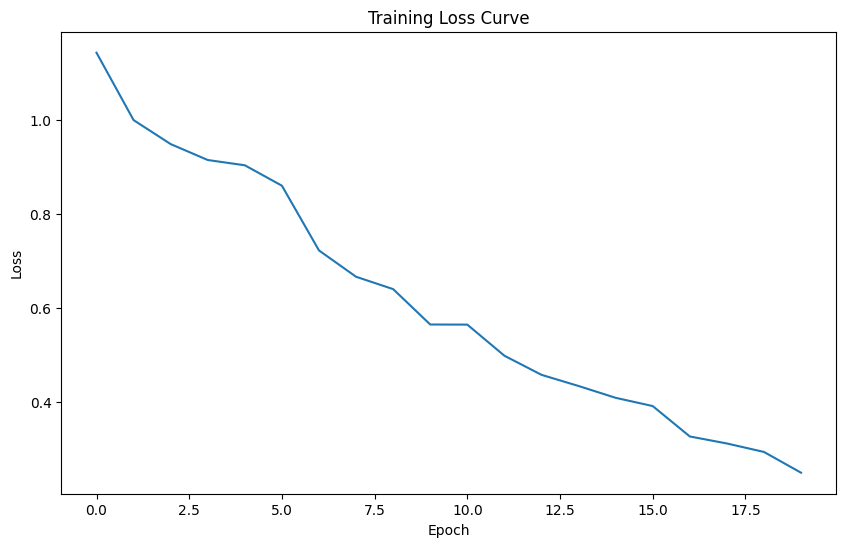

In [ ]:
# ============================================================
# 34. TRAINING LOSS CURVE
# ============================================================

plt.figure(figsize=(10,6))

plt.plot(train_losses)

plt.title("Training Loss Curve")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.savefig(
    f"{OUTPUT_DIR}/training_loss.png"
)

plt.show()

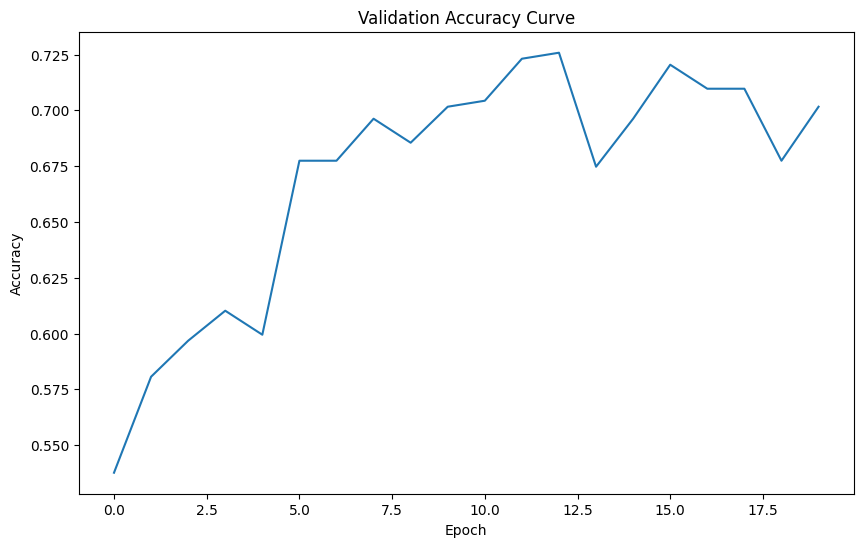

In [ ]:
# ============================================================
# 35. VALIDATION ACCURACY CURVE
# ============================================================

plt.figure(figsize=(10,6))

plt.plot(val_accuracies)

plt.title("Validation Accuracy Curve")

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.savefig(
    f"{OUTPUT_DIR}/training_accuracy.png"
)

plt.show()


In [ ]:
# ============================================================
# 36. GRADCAM
# ============================================================

target_layers = [
    model.layers[-1].blocks[-1].norm1
]

cam = GradCAM(

    model=model,

    target_layers=target_layers
)


In [ ]:
# ============================================================
# 37. GRADCAM FUNCTION
# ============================================================

def generate_gradcam(
    img_path,
    save_path
):

    rgb_img = cv2.imread(img_path)

    rgb_img = cv2.cvtColor(
        rgb_img,
        cv2.COLOR_BGR2RGB
    )

    rgb_img = cv2.resize(
        rgb_img,
        (224,224)
    )

    rgb_img_float = (
        np.float32(rgb_img) / 255.0
    )

    transform = transforms.Compose([

        transforms.ToTensor(),

        transforms.Normalize(

            mean=[0.485,0.456,0.406],

            std=[0.229,0.224,0.225]
        )
    ])

    input_tensor = transform(
        Image.fromarray(rgb_img)
    ).unsqueeze(0).to(device)

    grayscale_cam = cam(
        input_tensor=input_tensor
    )[0]

    visualization = show_cam_on_image(

        rgb_img_float,

        grayscale_cam,

        use_rgb=True
    )

    plt.figure(figsize=(6,6))

    plt.imshow(visualization)

    plt.axis('off')

    plt.savefig(save_path)

    plt.close()


In [ ]:
# ============================================================
# 38. SAVE CORRECT GRADCAM
# ============================================================

saved_classes = set()

model.eval()

for idx in range(len(val_dataset)):

    img, label = val_dataset[idx]

    input_tensor = img.unsqueeze(0).to(device)

    with torch.no_grad():

        outputs = model(input_tensor)

        pred = torch.argmax(
            outputs,
            dim=1
        ).item()

    if pred == label and label not in saved_classes:

        img_path = val_df_stage2.iloc[idx]["filepath"]

        save_path = (
            f"{OUTPUT_DIR}/gradcam/correct/"
            f"class_{label}.png"
        )

        generate_gradcam(
            img_path,
            save_path
        )

        saved_classes.add(label)

    if len(saved_classes) == 4:
        break


In [ ]:
# ============================================================
# 39. FINAL TWO-STAGE PREDICTION
# ============================================================

def predict_dr(img_path):

    # =========================
    # STAGE 1
    # =========================

    img = tf.keras.preprocessing.image.load_img(
        img_path,
        target_size=(224,224)
    )

    img_array = tf.keras.preprocessing.image.img_to_array(img)

    img_array = img_array / 255.0

    img_array = np.expand_dims(
        img_array,
        axis=0
    )

    binary_prob = binary_model.predict(
        img_array
    )[0][0]

    print("DR Probability:", binary_prob)

    if binary_prob < 0.3:
        return "No_DR"

    # =========================
    # STAGE 2
    # =========================

    transform = transforms.Compose([

        transforms.Resize((224,224)),

        transforms.ToTensor(),

        transforms.Normalize(

            mean=[0.485,0.456,0.406],

            std=[0.229,0.224,0.225]
        )
    ])

    image = Image.open(
        img_path
    ).convert("RGB")

    tensor = transform(
        image
    ).unsqueeze(0).to(device)

    model.eval()

    with torch.no_grad():

        outputs = model(tensor)

        pred = torch.argmax(
            outputs,
            dim=1
        ).item()

    return reverse_label_map[pred]


In [ ]:
# ============================================================
# 40. TEST PIPELINE
# ============================================================

sample_image = val_df.sample(1)[
    "filepath"
].values[0]

prediction = predict_dr(sample_image)

print("Final Prediction:", prediction)

1/1 ━━━━━━━━━━━━━━━━━━━━ 12s 12s/step
DR Probability: 0.0233683
Final Prediction: No_DR


In [ ]:
# ============================================================
# 41. ZIP OUTPUTS
# ============================================================

shutil.make_archive(

    "two_stage_outputs",

    'zip',

    OUTPUT_DIR
)

# ============================================================
# 42. DOWNLOAD
# ============================================================

from google.colab import files

files.download("two_stage_outputs.zip")

print("DONE")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

DONE
